In [18]:
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import numpy as np
import os
import shutil
import tarfile
from tqdm import tqdm
import nibabel as nib
import os

##  Download latest version of dataset

In [19]:
path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brats-2021-task1' dataset.
Path to dataset files: /kaggle/input/brats-2021-task1


## Show folders downloaded

In [20]:
base_path = path

print(os.listdir(base_path))

['BraTS2021_00495.tar', 'BraTS2021_Training_Data.tar', 'BraTS2021_00621.tar']


## Data Decompression and Extraction into Directory

In [23]:
working_dir = "/content/kaggle/working/"
os.makedirs(working_dir, exist_ok=True)

for item in os.listdir(working_dir):
    item_path = os.path.join(working_dir, item)
    if os.path.isfile(item_path) or os.path.islink(item_path):
        os.remove(item_path)
    elif os.path.isdir(item_path):
        shutil.rmtree(item_path)

print("Cleaned working directory.")

tar_path = os.path.join(base_path, "BraTS2021_Training_Data.tar")
extract_path = "/content/kaggle/working/BraTS2021"

os.makedirs(extract_path, exist_ok=True)

print("Extracting tar file...")

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path, filter="data")

print("Extraction Complete.")

Cleaned working directory.
Extracting tar file...
Extraction Complete.


## Number cases of patients

In [24]:
patients = [
    f for f in os.listdir(extract_path)
    if os.path.isdir(os.path.join(extract_path, f))
]

print("Cantidad de pacientes:", len(patients))

Cantidad de pacientes: 1251


In [25]:
print("Primeros 10 pacientes:")
print(patients[:10])

Primeros 10 pacientes:
['BraTS2021_01660', 'BraTS2021_01405', 'BraTS2021_01331', 'BraTS2021_01515', 'BraTS2021_00338', 'BraTS2021_01556', 'BraTS2021_01616', 'BraTS2021_00657', 'BraTS2021_00583', 'BraTS2021_01501']


## Exploration of MRI Modalities for a Patient Case

In [26]:
working_dir_one_patien = "/content/kaggle/working/BraTS2021/BraTS2021_00000"
flair = nib.load(os.path.join(working_dir_one_patien, "BraTS2021_00000_flair.nii.gz")).get_fdata()
t1 = nib.load(os.path.join(working_dir_one_patien, "BraTS2021_00000_t1.nii.gz")).get_fdata()
t1ce = nib.load(os.path.join(working_dir_one_patien, "BraTS2021_00000_t1ce.nii.gz")).get_fdata()
t2 = nib.load(os.path.join(working_dir_one_patien, "BraTS2021_00000_t2.nii.gz")).get_fdata()
seg = nib.load(os.path.join(working_dir_one_patien, "BraTS2021_00000_seg.nii.gz")).get_fdata()

print("Flair: ", flair.shape, "t1: ", t1.shape, "t1ce: ", t1ce.shape, "t2: ", t2.shape, "seg: ", seg.shape)

Flair:  (240, 240, 155) t1:  (240, 240, 155) t1ce:  (240, 240, 155) t2:  (240, 240, 155) seg:  (240, 240, 155)


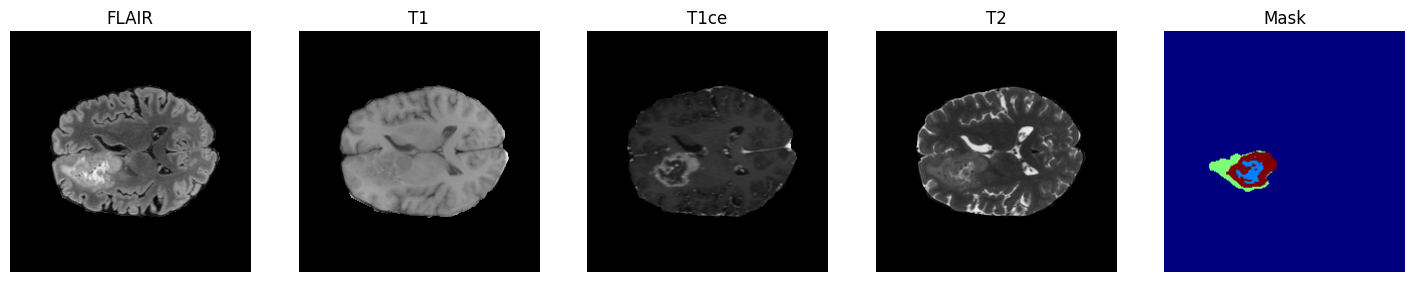

In [27]:
slice_idx = 80
fig, axes = plt.subplots(1, 5, figsize=(18,5))

axes[0].imshow(flair[:,:,slice_idx], cmap='gray')
axes[0].set_title("FLAIR")

axes[1].imshow(t1[:,:,slice_idx], cmap='gray')
axes[1].set_title("T1")

axes[2].imshow(t1ce[:,:,slice_idx], cmap='gray')
axes[2].set_title("T1ce")

axes[3].imshow(t2[:,:,slice_idx], cmap='gray')
axes[3].set_title("T2")

axes[4].imshow(seg[:,:,slice_idx], cmap='jet')
axes[4].set_title("Mask")

for ax in axes:
    ax.axis("off")

plt.show()

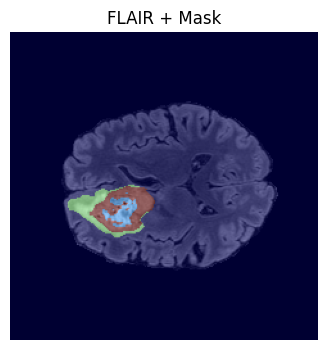

In [28]:
plt.figure(figsize=(4,4))
plt.imshow(flair[:,:,slice_idx], cmap='gray')
plt.imshow(seg[:,:,slice_idx], cmap='jet', alpha=0.4)
plt.title("FLAIR + Mask")
plt.axis("off")
plt.show()

## Classes of segmentation

In [29]:
classes = np.unique(seg)
print("Segmentation classes:", classes)

Segmentation classes: [0. 1. 2. 4.]


## Dataset Size

In [30]:
import os

def get_size(start_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(start_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    return total_size

size_bytes = get_size(extract_path)
size_gb = size_bytes / (1024**3)

print(f"Tamaño total: {size_gb:.2f} GB")

Tamaño total: 12.46 GB


In [ ]:
import os

patient_sizes = []

for patient in os.listdir(extract_path):
    patient_path = os.path.join(extract_path, patient)

    if os.path.isdir(patient_path):
        total_size = 0

        for file in os.listdir(patient_path):
            file_path = os.path.join(patient_path, file)
            total_size += os.path.getsize(file_path)

        size_mb = total_size / (1024**2)
        patient_sizes.append(size_mb)

import numpy as np

patient_sizes = np.array(patient_sizes)

print("Tamaño completo :", np.sum(patient_sizes), "MB")
print("Tamaño promedio:", np.mean(patient_sizes), "MB")
print("Tamaño mínimo:", np.min(patient_sizes), "MB")
print("Tamaño máximo:", np.max(patient_sizes), "MB")

Tamaño completo : 12763.277646064758 MB
Tamaño promedio: 10.20246014873282 MB
Tamaño mínimo: 4.884795188903809 MB
Tamaño máximo: 25.659175872802734 MB
